In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
from google.colab import files
uploaded = files.upload()

df = pd.read_csv(list(uploaded.keys())[0])
df.head()

Saving credit_risk_dataset.csv to credit_risk_dataset.csv


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [3]:
# Fill missing values
df['person_emp_length'] = df['person_emp_length'].fillna(df['person_emp_length'].median())

# Fix unrealistic values
df['person_emp_length'] = df['person_emp_length'].clip(0, 40)

# Remove invalid rows
df = df[df['person_income'] > 0]
df = df[(df['person_age'] >= 18) & (df['person_age'] <= 80)]
df = df[df['loan_percent_income'] <= 1]

In [4]:
# Binary encoding
df['cb_person_default_on_file'] = df['cb_person_default_on_file'].map({'Y':1, 'N':0})

# One-hot encoding (ALL object columns safely)
df = pd.get_dummies(df, drop_first=True)

# Convert everything to numeric
df = df.apply(pd.to_numeric, errors='coerce')

In [5]:
# Remove infinities and NaN
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna()

In [6]:
X = df.drop('loan_status', axis=1)
y = df['loan_status']

print(X.shape, y.shape)

(29460, 22) (29460,)


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [8]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

print("Model trained successfully ✅")

Model trained successfully ✅


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy: 0.8511541072640869


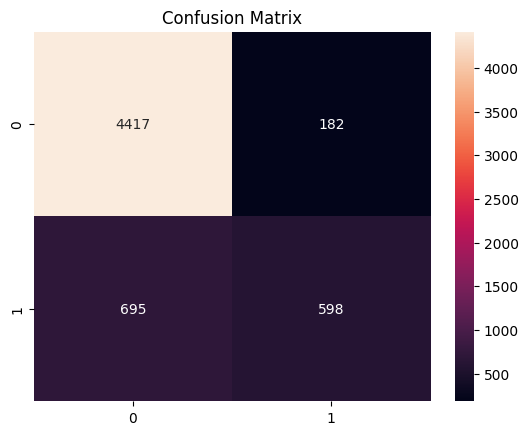

              precision    recall  f1-score   support

           0       0.86      0.96      0.91      4599
           1       0.77      0.46      0.58      1293

    accuracy                           0.85      5892
   macro avg       0.82      0.71      0.74      5892
weighted avg       0.84      0.85      0.84      5892



In [9]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

print(classification_report(y_test, y_pred))

In [10]:
y_prob = model.predict_proba(X_test)[:, 1]

threshold = 0.4
y_pred_custom = (y_prob >= threshold).astype(int)

print("Accuracy (threshold=0.4):", accuracy_score(y_test, y_pred_custom))

Accuracy (threshold=0.4): 0.8518329938900203


In [11]:
pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
}).sort_values(by="Coefficient", ascending=False)

,Feature,Coefficient
19,loan_grade_E,0.898655
18,loan_grade_D,0.849975
5,loan_percent_income,0.770566
10,person_home_ownership_RENT,0.664720
12,loan_intent_HOMEIMPROVEMENT,0.318692
20,loan_grade_F,0.266171
21,loan_grade_G,0.203457
4,loan_int_rate,0.188046
6,cb_person_default_on_file,0.080630
8,person_home_ownership_OTHER,0.075836


## Conclusion

- Data was cleaned and prepared for modeling  
- Logistic Regression used for default prediction  
- Key drivers: income, loan ratio, interest rate, credit history  
- Threshold tuning helps control financial risk  

This model supports better lending decisions.